In [1]:
# read excel file 
import pandas as pd
import numpy as np
import os 
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# read excel file
print(os.getcwd())
df = pd.read_excel('../playground/data/final_data_export.xlsx')
df


c:\Users\ja.borowski\MS_thesis\playground


,person_x,kinsman,person_gender,kinsman_gender,ontology_kinship
0,"Aaron, brother of Alousianos","John Vladislav, ruler of Bulgaria",Male,Male,SonOf
1,"Adrianos Komnenos, brother of Alexios I",Anna Dalassene,Male,Female,SonOf
2,"Akindynos, tax-payer at chorion of Dobrobikeia","Kaletza, mother of tax-payer at Dobrobikeia",Male,Female,SonOf
3,"'Allaf, son of Hassan ibn al-Mufarrij",Hassan ibn al-Mufarrij ibn al-Jarrah (Pinzarach),Male,Male,SonOf
4,Emperor Alexios I Komnenos,Anna Dalassene,Male,Female,SonOf
...,...,...,...,...,...
2786,"Eudokia Komnene, sister of Alexios I, wife of ...","Ioannes Komnenos, father of Alexios I",Female,Male,DaughterOf
2787,"Anna Doukaina, sister of Eirene Doukaina and w...","Andronikos Doukas, son of the kaisar Ioannes",Female,Male,DaughterOf
2788,"Anna Doukaina, sister of Eirene Doukaina and w...","Maria of Bulgaria, wife of Andronikos Doukas",Female,Female,DaughterOf
2789,"Romuald, prominent person in Bari, full brothe...","Petros, prominent person in Bari, full brother...",Male,Male,BrotherOf


In [2]:
## Create a graph 
G = nx.Graph()

In [3]:
## Generate list of persons in data 
node_list = list(df['person_x'].unique())
node_list.extend(list(df['kinsman'].unique()))
node_list = list(set(node_list))


In [4]:
# Number of uniqe persons in relations
len(node_list)

1625

In [5]:
# add nodes to graph 
G.add_nodes_from(node_list)

In [6]:
# add edges to graph
for i in range(len(df)):
    G.add_edge(df['person_x'][i], df['kinsman'][i], name = df['ontology_kinship'][i])

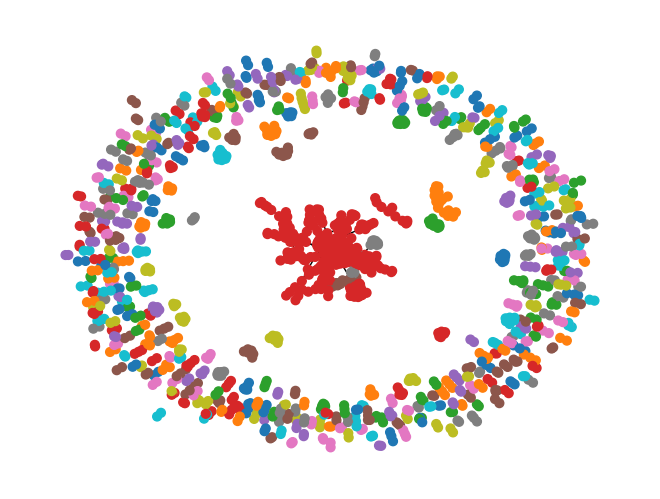

In [7]:

# Print graph 
components = list(nx.connected_components(G))

# Generate a color map
colors = list(mcolors.TABLEAU_COLORS.keys())  # A set of predefined colors
color_map = {}

# Assign a unique color to each component
for i, component in enumerate(components):
    for node in component:
        color_map[node] = colors[i % len(colors)]  # Cycle through colors if needed

# Extract colors for nodes
node_colors = [color_map[node] for node in G.nodes]

# Draw the graph
pos = nx.spring_layout(G)  # Layout for positioning
nx.draw(G, pos, node_color=node_colors, node_size=40)
plt.show()

In [8]:
# unconected subgraphs 
sub_graphs=sorted(nx.connected_components(G), key=len, reverse=True)
subgrpahs_len=[len(i) for i in sub_graphs]




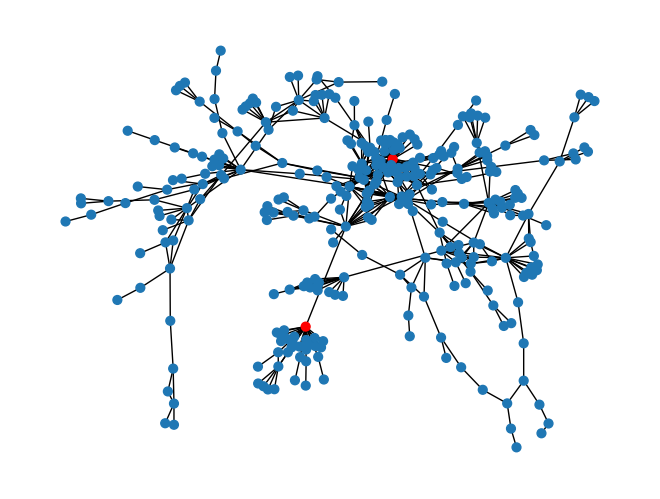

In [13]:
# Print graph 
sub_G = G.subgraph(sub_graphs[0])
components = list(nx.connected_components(sub_G))

# Generate a color map
colors = list(mcolors.TABLEAU_COLORS.keys())  # A set of predefined colors
color_map = {}

# Assign a unique color to each component
for i, component in enumerate(components):
    for node in component:
        color_map[node] = colors[i % len(colors)]  # Cycle through colors if needed

# Extract colors for nodes
node_colors = [color_map[node] for node in sub_G.nodes]

degree_dict = dict(sub_G.degree())
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:2]

# Mark the top-degree nodes as red
for i, node in enumerate(sub_G.nodes):
    if node in top_nodes:
        node_colors[i] = "red"

# Draw the graph
pos = nx.spring_layout(sub_G)  # Layout for positioning
nx.draw(sub_G, pos, node_color=node_colors, node_size=40)
plt.show()

In [10]:
pd.Series(subgrpahs_len).value_counts(sort=False)

326      1
22       1
16       1
11       2
10       3
9        1
8        3
7        5
6       11
5       15
4       32
3       76
2      322
Name: count, dtype: int64

In [15]:
num_edges = sub_G.number_of_edges()
num_vertices = sub_G.number_of_nodes()

# Calculate the average edges per vertex
avg_edges_per_vertex = (2 * num_edges) / num_vertices
avg_edges_per_vertex

3.276073619631902

In [16]:
nx.average_shortest_path_length(sub_G)

6.013855592260501

In [11]:
def generate_data_for_sub_graph(sub_graph,df):
    new_df = df.copy()
    row_to_remove = []
    for i in range(len(new_df)):
        if new_df['person_x'][i] not in sub_graph or new_df['kinsman'][i] not in sub_graph:
            row_to_remove.append(i)
    new_df = new_df.drop(row_to_remove)
    return new_df

In [12]:
def unpack_list(lists): 
    new_set = set()
    for i in lists:
        for j in i:
            new_set.add(j)
    return new_set

In [13]:
new_data = generate_data_for_sub_graph(sub_graphs[0],df)
# save to excel 
new_data.to_excel('../code/out/final_data_sub_graph_1_c.xlsx', index = False)

In [14]:
new_data = generate_data_for_sub_graph(unpack_list(sub_graphs[1:100]),df)
# save to excel
new_data.to_excel('../code/out/final_data_sub_graph_2_c.xlsx', index = False)

In [15]:
new_data = generate_data_for_sub_graph(unpack_list(sub_graphs[100:]),df)
# save to excel
new_data.to_excel('../code/out/final_data_sub_graph_3_c.xlsx', index = False)

,person_x,kinsman,person_gender,kinsman_gender,ontology_kinship
15,"son of Aleim, the commander of the fort of Ber...","Aleim, Arab commander of the fort of Berkri",Male,Male,SonOf
16,son of amir of Sicily Apolaphar Mouchoumet,"Ahmad al-Akhal, amir of Sicily",Male,Male,SonOf
19,"Boioannes, katepano of Italy in 1040s","Basileios Boioannes, katepano of Italy in 1020s",Male,Male,SonOf
24,son of Katakalon Klazomenites,"Katakalon Klazomenites, strategos of Ragusa",Male,Male,SonOf
26,"son of Dobronas, ruler of Zara and Salona","Dobronas, ruler of Zadar and Split",Male,Male,SonOf
...,...,...,...,...,...
2938,daughter of magistros Gorgoploutos,husband of the daughter of Gorgoploutos,Female,Male,ExWifeOf
2940,husband of the daughter of Gorgoploutos,daughter of magistros Gorgoploutos,Male,Female,ExHusbandOf
2949,"Nikolaos, protospatharios and man of krites of...","Christophoros, krites of the velon and of Bole...",Male,Male,RelativeOf
2955,"Eugenios, kouboukleisios, subordinate of krite...","Niketas Xiphilinos, krites and anagrapheus of ...",Male,Male,RelativeOf


In [ ]:
degrees = [deg for _, deg in G.degree()]
avg_degree = sum(degrees) / len(degrees)
print(f"Average Degree: {avg_degree}")


Average Degree: 1.796856106408706


AttributeError: 'DegreeView' object has no attribute 'count'

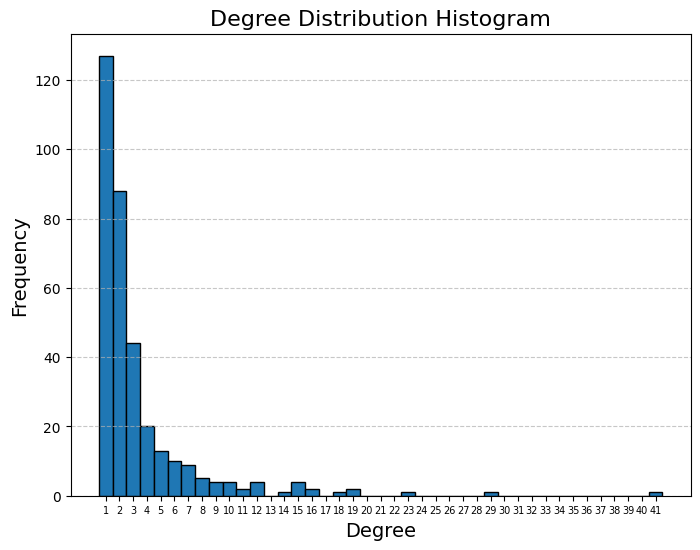

In [26]:
degrees = [deg for _, deg in sub_G.degree()]

# Plot the histogram
plt.figure(figsize=(8, 6))
plt.hist(degrees, bins=range(min(degrees), max(degrees) + 2), edgecolor='black', align='left')
plt.title("Degree Distribution Histogram", fontsize=16)
plt.xlabel("Degree", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(min(degrees), max(degrees) + 1),fontsize=7)
plt.show()

In [28]:
nx.density(sub_G)

0.009752271836052716

In [30]:
from networkx.algorithms.community import modularity
modularity(sub_G, nx.algorithms.community.label_propagation.label_propagation_communities(sub_G))

0.6666462907721649

In [31]:
nx.closeness_centrality(sub_G)

{'Geza I, king of Hungary': 0.15914378780828292,
 'Theodora - Xene Komnene, sister of Alexios I Komnenos': 0.21839080459770116,
 'wife of brother of Michael Keroularios': 0.19031719532554256,
 'Theodoros Dokeianos': 0.2207876049063912,
 'king (?) of Alania': 0.1873972602739726,
 'Demetrios, son of Giorgi I of Abchasia/Georgia': 0.1385737439222042,
 'Emperor Romanos III Argyros': 0.21215880893300249,
 'young kinsman of Alexios I': 0.20565243535778713,
 'Konstantinos, nephew of patriarch Michael I Keroularios': 0.23472889498970487,
 '(Elizabeth), mother of Joscelin I, aunt of Baldwin II': 0.15951492537313433,
 'wife of Gagik II, sister of David of Dvin': 0.11748540020611474,
 'Theodosios Monomachos, father of Konstantinos IX': 0.17466802860061287,
 'Euboulos, son-in-law of Robert Guiscard (count Ebalus of Roucy?)': 0.16277962874821514,
 '(Ioannes) Bryennios the patrikios, father of the kaisar': 0.21923076923076923,
 'wife of Leon Pegonites': 0.15877437325905291,
 '(?) William of Boulogne

In [8]:
from networkx.algorithms.community import modularity_max

communities = modularity_max.greedy_modularity_communities(sub_G)
print("Number of Communities:", len(communities))

Number of Communities: 15


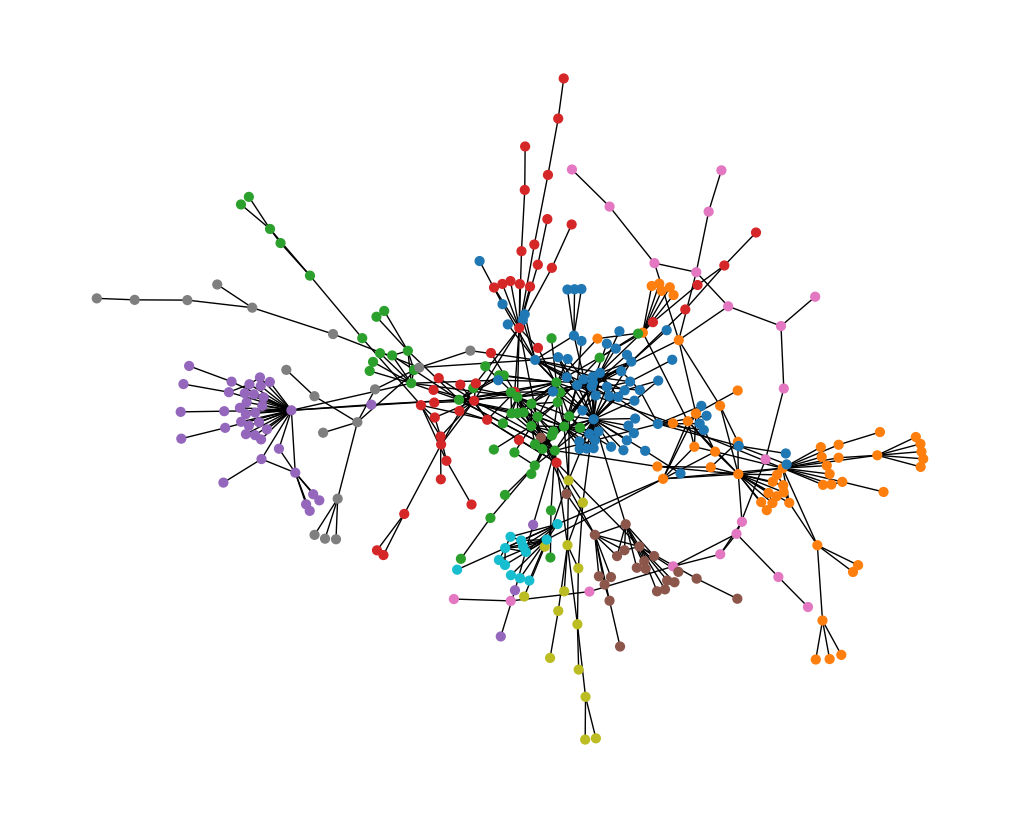

In [9]:
from matplotlib.colors import TABLEAU_COLORS

colors = list(TABLEAU_COLORS.keys())  # Predefined color palette
node_colors = {}

# Assign a color to each community
for i, community in enumerate(communities):
    for node in community:
        node_colors[node] = colors[i % len(colors)]  # Cycle through colors if needed

# Create a list of colors for the graph nodes
node_color_list = [node_colors[node] for node in sub_G.nodes]

# Draw the graph
pos = nx.spring_layout(sub_G)  # Layout for positioning nodes
plt.figure(figsize=(10, 8))
nx.draw(sub_G, pos, node_color=node_color_list, with_labels=False, node_size=40, font_size=10)
plt.show()